In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
worldcups = pd.read_csv("/content/WorldCups.csv")
matches = pd.read_csv("/content/WorldCupMatches.csv")
players = pd.read_csv("/content/WorldCupPlayers.csv")

print("World Cups:", worldcups.shape)
print("Matches:", matches.shape)
print("Players:", players.shape)

World Cups: (20, 10)
Matches: (4572, 20)
Players: (37784, 9)


In [6]:
print(worldcups.info())
print(matches.info())
print(players.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            20 non-null     int64 
 1   Country         20 non-null     object
 2   Winner          20 non-null     object
 3   Runners-Up      20 non-null     object
 4   Third           20 non-null     object
 5   Fourth          20 non-null     object
 6   GoalsScored     20 non-null     int64 
 7   QualifiedTeams  20 non-null     int64 
 8   MatchesPlayed   20 non-null     int64 
 9   Attendance      20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    object 
 2 

In [7]:
print("World Cups Missing Values")
print(worldcups.isnull().sum())

print("\nMatches Missing Values")
print(matches.isnull().sum())

print("\nPlayers Missing Values")
print(players.isnull().sum())

World Cups Missing Values
Year              0
Country           0
Winner            0
Runners-Up        0
Third             0
Fourth            0
GoalsScored       0
QualifiedTeams    0
MatchesPlayed     0
Attendance        0
dtype: int64

Matches Missing Values
Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64

Players Missing Values
RoundID              0
MatchID              0
Team Initials        0
Coach Name           0
Line-up              0
Shirt

In [8]:
winner_counts = worldcups["Winner"].value_counts()

print(winner_counts)

Winner
Brazil        5
Italy         4
Germany FR    3
Uruguay       2
Argentina     2
England       1
France        1
Spain         1
Germany       1
Name: count, dtype: int64


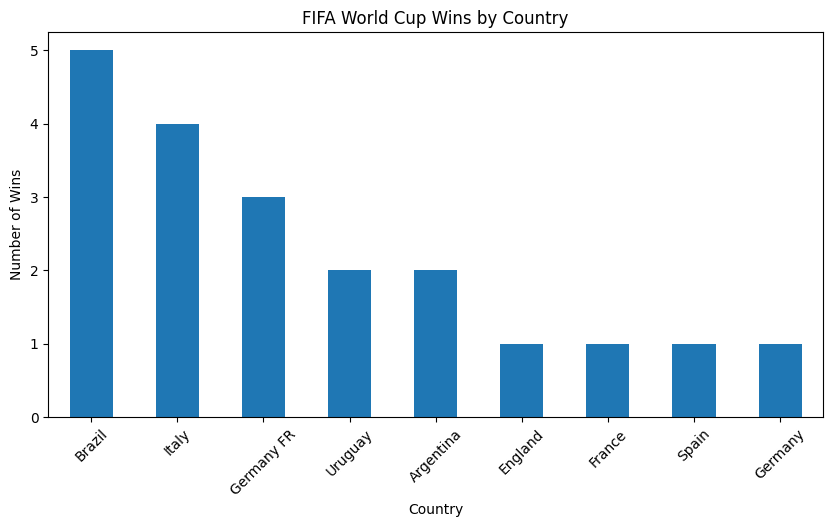

In [9]:
plt.figure(figsize=(10,5))

winner_counts.plot(kind="bar")

plt.title("FIFA World Cup Wins by Country")
plt.xlabel("Country")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)

plt.show()

In [10]:
runner_up_counts = worldcups["Runners-Up"].value_counts()

print(runner_up_counts)

Runners-Up
Argentina         3
Germany FR        3
Netherlands       3
Czechoslovakia    2
Brazil            2
Hungary           2
Italy             2
Sweden            1
Germany           1
France            1
Name: count, dtype: int64


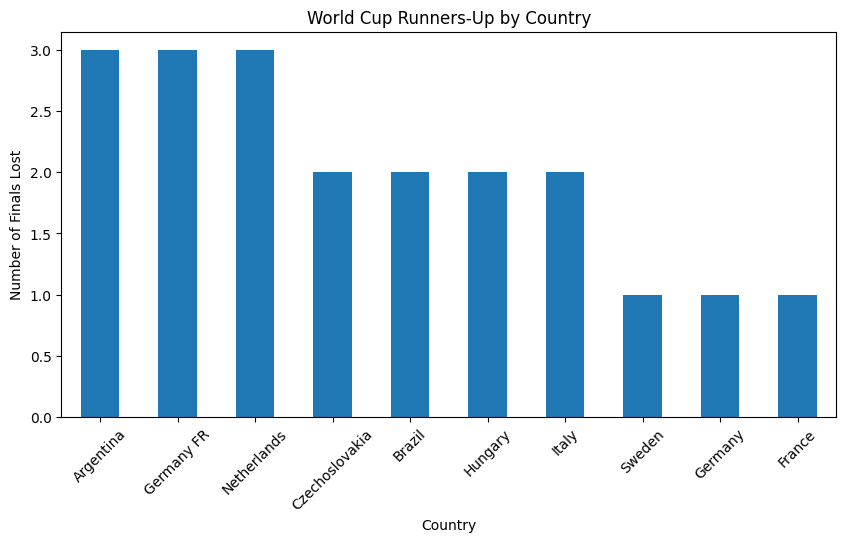

In [11]:
plt.figure(figsize=(10,5))

runner_up_counts.plot(kind="bar")

plt.title("World Cup Runners-Up by Country")
plt.xlabel("Country")
plt.ylabel("Number of Finals Lost")

plt.xticks(rotation=45)

plt.show()

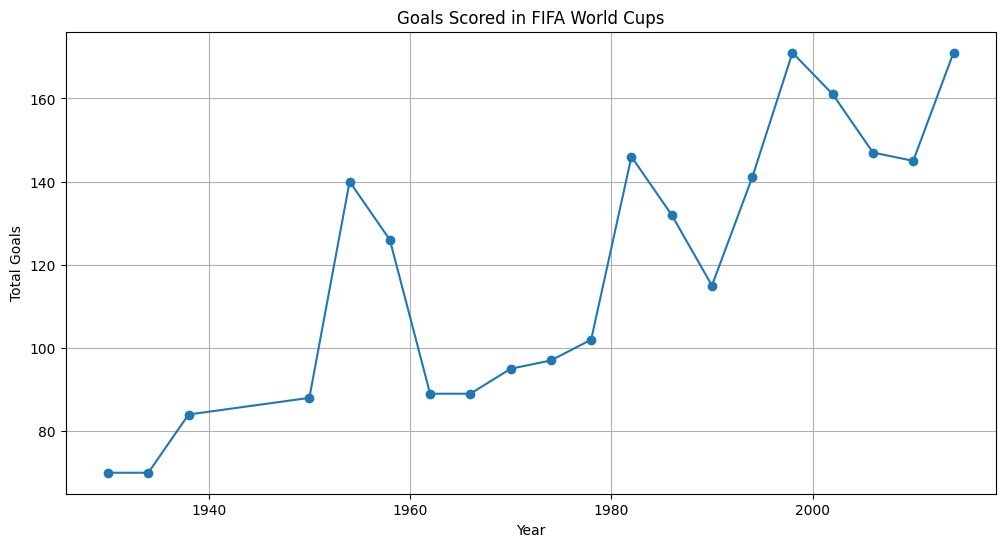

In [12]:
plt.figure(figsize=(12,6))

plt.plot(
    worldcups["Year"],
    worldcups["GoalsScored"],
    marker="o"
)

plt.title("Goals Scored in FIFA World Cups")
plt.xlabel("Year")
plt.ylabel("Total Goals")
plt.grid(True)

plt.show()

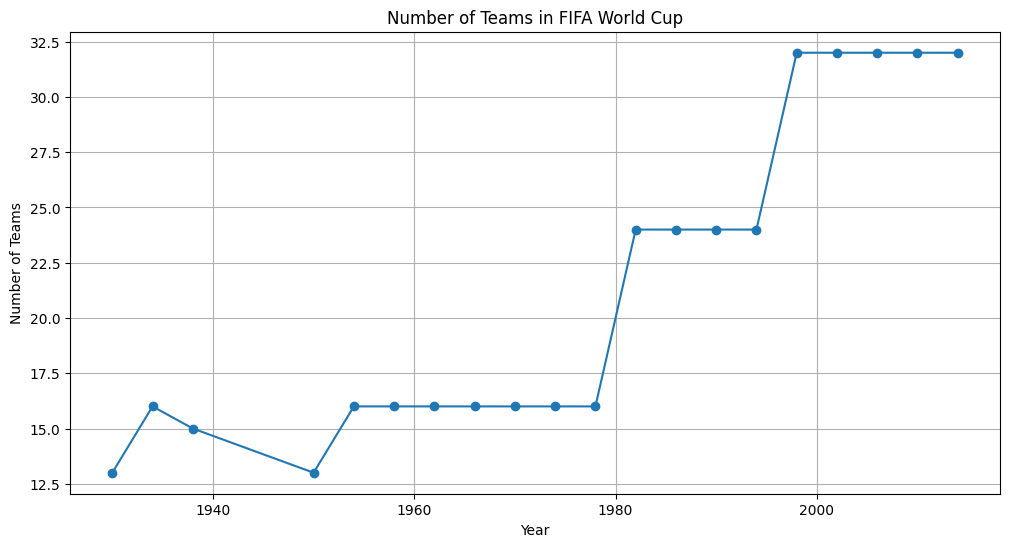

In [13]:
plt.figure(figsize=(12,6))

plt.plot(
    worldcups["Year"],
    worldcups["QualifiedTeams"],
    marker="o"
)

plt.title("Number of Teams in FIFA World Cup")
plt.xlabel("Year")
plt.ylabel("Number of Teams")
plt.grid(True)

plt.show()

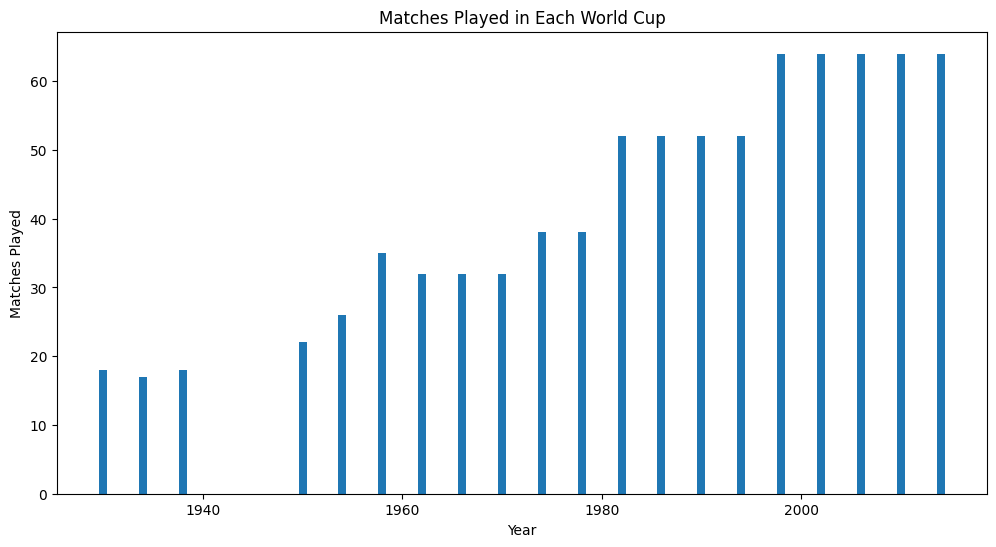

In [14]:
plt.figure(figsize=(12,6))

plt.bar(
    worldcups["Year"],
    worldcups["MatchesPlayed"]
)

plt.title("Matches Played in Each World Cup")
plt.xlabel("Year")
plt.ylabel("Matches Played")

plt.show()

In [15]:
worldcups["GoalsPerMatch"] = (
    worldcups["GoalsScored"] /
    worldcups["MatchesPlayed"]
)

print(
    worldcups[
        ["Year", "GoalsScored", "MatchesPlayed", "GoalsPerMatch"]
    ]
)

    Year  GoalsScored  MatchesPlayed  GoalsPerMatch
0   1930           70             18       3.888889
1   1934           70             17       4.117647
2   1938           84             18       4.666667
3   1950           88             22       4.000000
4   1954          140             26       5.384615
5   1958          126             35       3.600000
6   1962           89             32       2.781250
7   1966           89             32       2.781250
8   1970           95             32       2.968750
9   1974           97             38       2.552632
10  1978          102             38       2.684211
11  1982          146             52       2.807692
12  1986          132             52       2.538462
13  1990          115             52       2.211538
14  1994          141             52       2.711538
15  1998          171             64       2.671875
16  2002          161             64       2.515625
17  2006          147             64       2.296875
18  2010    

In [16]:
highest_scoring = worldcups.loc[
    worldcups["GoalsPerMatch"].idxmax()
]

print(highest_scoring)

Year                     1954
Country           Switzerland
Winner             Germany FR
Runners-Up            Hungary
Third                 Austria
Fourth                Uruguay
GoalsScored               140
QualifiedTeams             16
MatchesPlayed              26
Attendance            768.607
GoalsPerMatch        5.384615
Name: 4, dtype: object


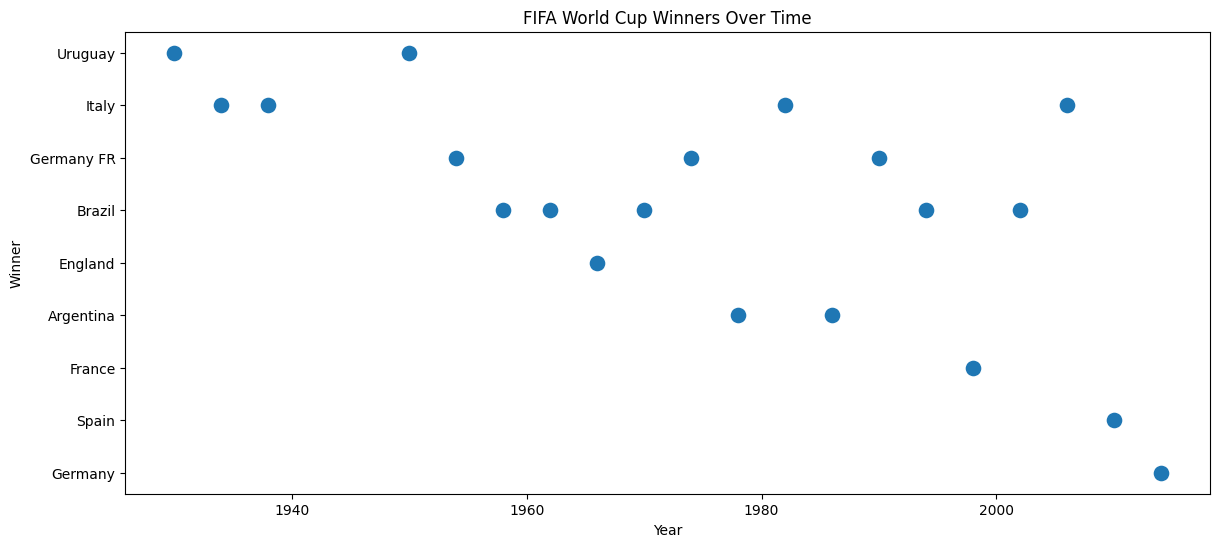

In [17]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=worldcups,
    x="Year",
    y="Winner",
    s=150
)

plt.title("FIFA World Cup Winners Over Time")
plt.xlabel("Year")
plt.ylabel("Winner")

plt.show()

In [18]:
host_counts = worldcups["Country"].value_counts()

print(host_counts)

Country
Italy           2
France          2
Brazil          2
Germany         2
Mexico          2
Uruguay         1
Switzerland     1
Chile           1
Sweden          1
England         1
Argentina       1
Spain           1
USA             1
Korea/Japan     1
South Africa    1
Name: count, dtype: int64


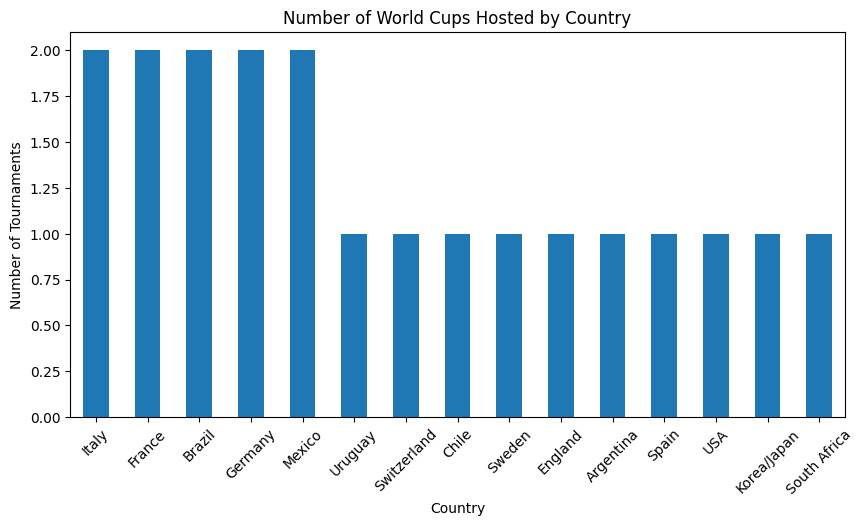

In [19]:
plt.figure(figsize=(10,5))

host_counts.plot(kind="bar")

plt.title("Number of World Cups Hosted by Country")
plt.xlabel("Country")
plt.ylabel("Number of Tournaments")

plt.xticks(rotation=45)

plt.show()

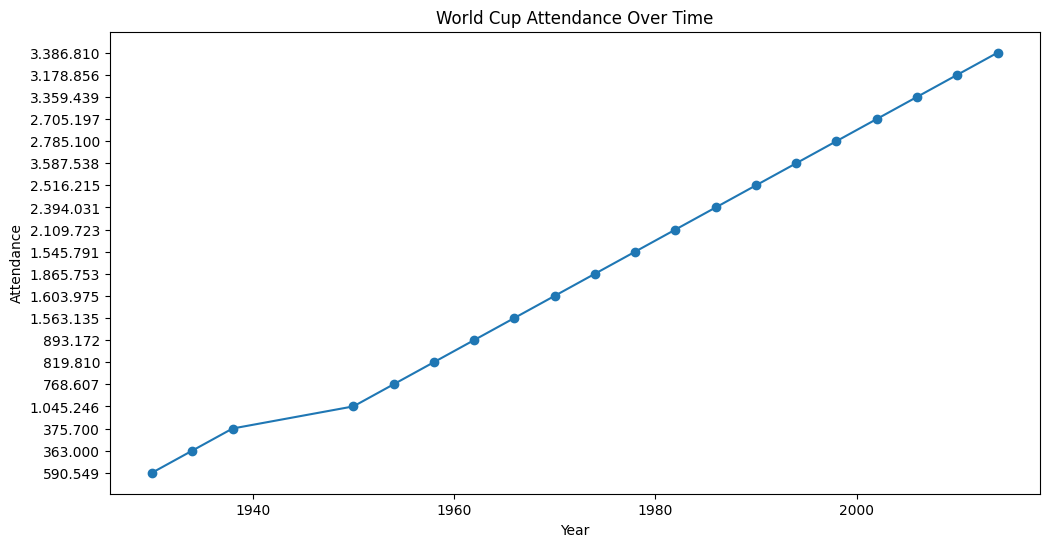

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    worldcups["Year"],
    worldcups["Attendance"],
    marker="o"
)

plt.title("World Cup Attendance Over Time")
plt.xlabel("Year")
plt.ylabel("Attendance")

plt.show()

In [21]:
highest_attendance = worldcups.loc[
    worldcups["Attendance"].idxmax()
]

print(highest_attendance)

Year                        1962
Country                    Chile
Winner                    Brazil
Runners-Up        Czechoslovakia
Third                      Chile
Fourth                Yugoslavia
GoalsScored                   89
QualifiedTeams                16
MatchesPlayed                 32
Attendance               893.172
GoalsPerMatch            2.78125
Name: 6, dtype: object


In [22]:
home_goals = matches["Home Team Goals"].sum()
away_goals = matches["Away Team Goals"].sum()

print("Home Goals:", home_goals)
print("Away Goals:", away_goals)

Home Goals: 1543.0
Away Goals: 871.0


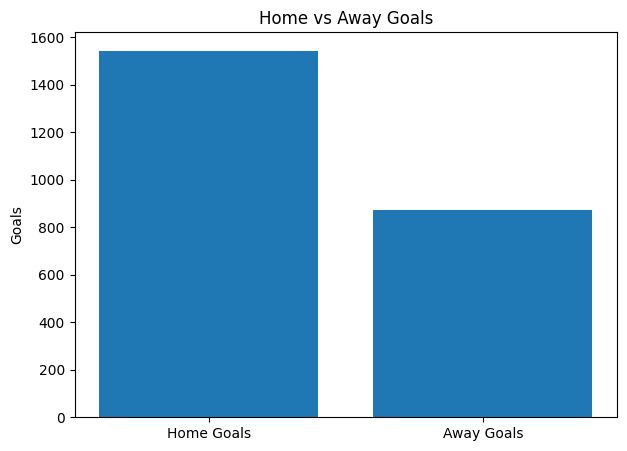

In [23]:
goals = {
    "Home Goals": home_goals,
    "Away Goals": away_goals
}

plt.figure(figsize=(7,5))

plt.bar(goals.keys(), goals.values())

plt.title("Home vs Away Goals")
plt.ylabel("Goals")

plt.show()

In [24]:
home_wins = (
    matches["Home Team Goals"] >
    matches["Away Team Goals"]
).sum()

away_wins = (
    matches["Away Team Goals"] >
    matches["Home Team Goals"]
).sum()

draws = (
    matches["Home Team Goals"] ==
    matches["Away Team Goals"]
).sum()

print("Home Wins:", home_wins)
print("Away Wins:", away_wins)
print("Draws:", draws)

Home Wins: 488
Away Wins: 174
Draws: 190


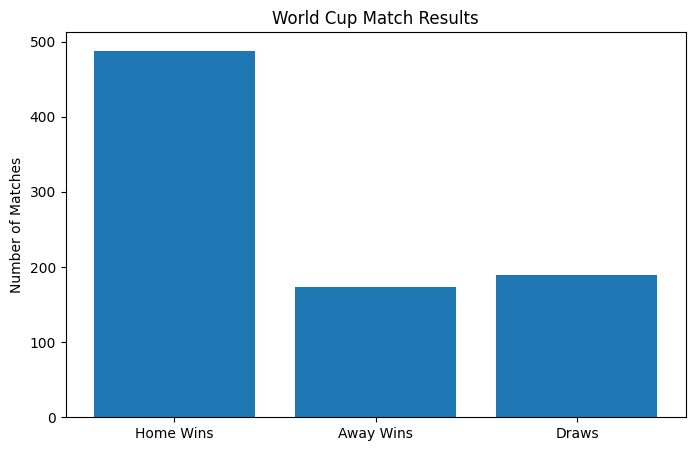

In [25]:
results = {
    "Home Wins": home_wins,
    "Away Wins": away_wins,
    "Draws": draws
}

plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("World Cup Match Results")
plt.ylabel("Number of Matches")

plt.show()

In [26]:
positions = pd.concat([
    worldcups["Winner"],
    worldcups["Runners-Up"],
    worldcups["Third"],
    worldcups["Fourth"]
])

print(positions.value_counts().head(10))

Brazil         11
Germany FR      8
Italy           8
Uruguay         5
Argentina       5
Germany         5
France          5
Netherlands     5
Sweden          4
Spain           2
Name: count, dtype: int64


In [27]:
print(players["Player Name"].nunique())

7663


In [28]:
position_counts = players["Position"].value_counts()

print(position_counts)

Position
GK     2441
C      1510
GKC     192
Name: count, dtype: int64


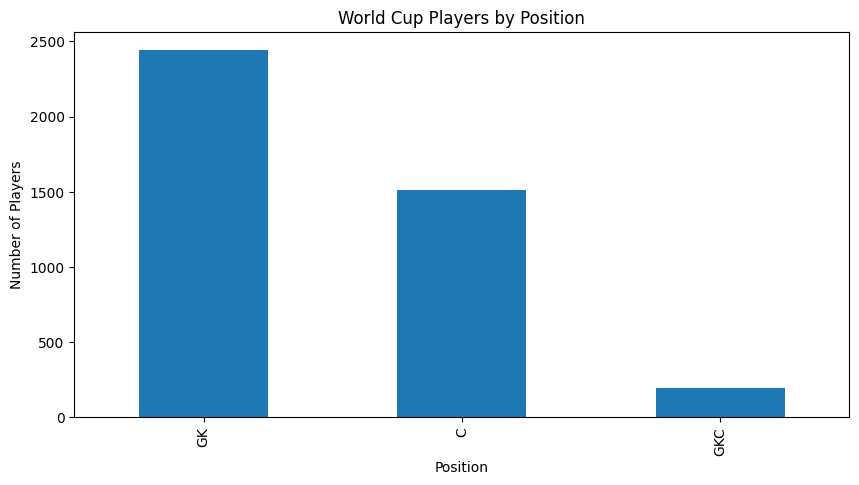

In [29]:
plt.figure(figsize=(10,5))

position_counts.plot(kind="bar")

plt.title("World Cup Players by Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")

plt.show()

In [30]:
print(players["Event"].value_counts().head(20))

Event
OH46'    247
IH46'    206
Y1'       87
I77'      78
I78'      78
I72'      77
I73'      77
O75'      73
I75'      73
I70'      73
I74'      72
O72'      70
O78'      66
I80'      66
I66'      66
I68'      65
O77'      65
I67'      65
I69'      64
I83'      64
Name: count, dtype: int64


In [31]:
home_wins = matches[
    matches["Home Team Goals"] > matches["Away Team Goals"]
]["Home Team Name"].value_counts()

away_wins = matches[
    matches["Away Team Goals"] > matches["Home Team Goals"]
]["Away Team Name"].value_counts()

total_wins = home_wins.add(away_wins, fill_value=0)

print(total_wins.sort_values(ascending=False).head(10))

Brazil         71.0
Italy          45.0
Argentina      44.0
Germany FR     36.0
Germany        34.0
France         29.0
Spain          29.0
Netherlands    29.0
England        26.0
Uruguay        20.0
Name: count, dtype: float64


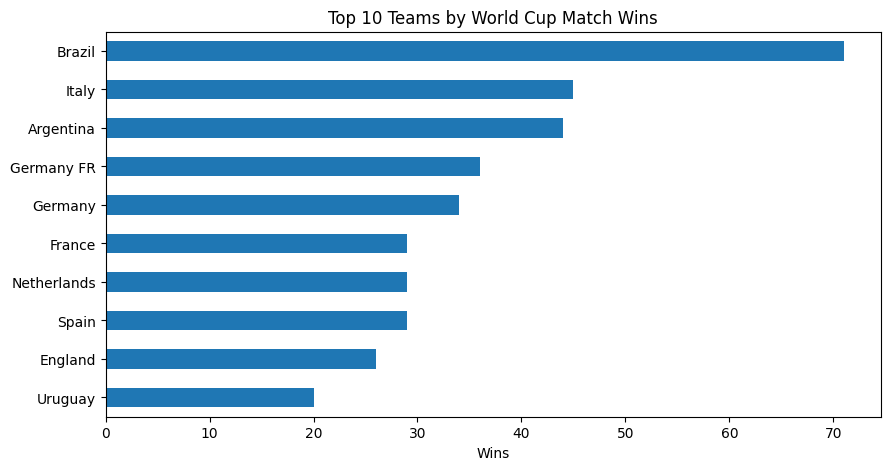

In [32]:
top_winners = total_wins.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

top_winners.sort_values().plot(kind="barh")

plt.title("Top 10 Teams by World Cup Match Wins")
plt.xlabel("Wins")

plt.show()